# Setup

In [1]:
from IPython.display import HTML, IFrame, clear_output, display
import random
from rich import print as rprint
from rich.table import Table
from tqdm.auto import tqdm
from functools import partial
import torch as t
import torch.nn.functional as F
from torch import Tensor, nn
from jaxtyping import Float, Int
import einops

import matplotlib.pyplot as plt
import numpy as np

device = t.device("mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu")

from sae_lens import (
    SAE,
    ActivationsStore,
    HookedSAETransformer,
    LanguageModelSAERunnerConfig,
    SAEConfig,
    SAETrainingRunner,
    upload_saes_to_huggingface,
)

from transformer_lens import ActivationCache, HookedTransformer, utils
from transformer_lens.hook_points import HookPoint
from tabulate import tabulate

In [2]:
# from huggingface_hub import login
# login()

In [3]:
# gemma-2-2b has layer 0 to layer 25

gemmascope_sae_release = "gemma-scope-2b-pt-mlp-canonical"
# gemmascope_sae_id = "layer_20/width_16k/canonical"
gemmascope_all_sae_ids = [
    f"layer_{i}/width_16k/canonical" for i in range(0,26)
]

In [4]:
gemmascope_all_sae_ids

['layer_0/width_16k/canonical',
 'layer_1/width_16k/canonical',
 'layer_2/width_16k/canonical',
 'layer_3/width_16k/canonical',
 'layer_4/width_16k/canonical',
 'layer_5/width_16k/canonical',
 'layer_6/width_16k/canonical',
 'layer_7/width_16k/canonical',
 'layer_8/width_16k/canonical',
 'layer_9/width_16k/canonical',
 'layer_10/width_16k/canonical',
 'layer_11/width_16k/canonical',
 'layer_12/width_16k/canonical',
 'layer_13/width_16k/canonical',
 'layer_14/width_16k/canonical',
 'layer_15/width_16k/canonical',
 'layer_16/width_16k/canonical',
 'layer_17/width_16k/canonical',
 'layer_18/width_16k/canonical',
 'layer_19/width_16k/canonical',
 'layer_20/width_16k/canonical',
 'layer_21/width_16k/canonical',
 'layer_22/width_16k/canonical',
 'layer_23/width_16k/canonical',
 'layer_24/width_16k/canonical',
 'layer_25/width_16k/canonical']

In [5]:
gemma_2_2b = HookedSAETransformer.from_pretrained("gemma-2-2b", device=device)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model gemma-2-2b into HookedTransformer


In [6]:
# gemma_2_2b_sae = SAE.from_pretrained(gemmascope_sae_release, gemmascope_sae_id, device=str(device))[0]
gemma_2_2b_all_sae = [
    SAE.from_pretrained(gemmascope_sae_release, i, device=str(device))[0] for i in gemmascope_all_sae_ids
]

C:\Anaconda\envs\fyp_gemma_testing\Lib\site-packages\sae_lens\saes\sae.py:249: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(
C:\Users\Pey Ruo-Yang\AppData\Local\Temp\ipykernel_25608\3035216223.py:3: DeprecationWarning: Indexing SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  SAE.from_pretrained(gemmascope_sae_release, i, device=str(device))[0] for i in gemmascope_all_sae_ids
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: c33cd480-780d-440a-9227-dacf5c16b7e2)')' thrown while requesting HEAD https://huggingface.co/google/gemma-scope-2b-pt-mlp/resolve/main/layer_4/width_16k/average_l0_85/params.npz
Re

In [7]:
gemma_2_2b_all_sae

[JumpReLUSAE(
   (activation_fn): ReLU()
   (hook_sae_input): HookPoint()
   (hook_sae_acts_pre): HookPoint()
   (hook_sae_acts_post): HookPoint()
   (hook_sae_output): HookPoint()
   (hook_sae_recons): HookPoint()
   (hook_sae_error): HookPoint()
 ),
 JumpReLUSAE(
   (activation_fn): ReLU()
   (hook_sae_input): HookPoint()
   (hook_sae_acts_pre): HookPoint()
   (hook_sae_acts_post): HookPoint()
   (hook_sae_output): HookPoint()
   (hook_sae_recons): HookPoint()
   (hook_sae_error): HookPoint()
 ),
 JumpReLUSAE(
   (activation_fn): ReLU()
   (hook_sae_input): HookPoint()
   (hook_sae_acts_pre): HookPoint()
   (hook_sae_acts_post): HookPoint()
   (hook_sae_output): HookPoint()
   (hook_sae_recons): HookPoint()
   (hook_sae_error): HookPoint()
 ),
 JumpReLUSAE(
   (activation_fn): ReLU()
   (hook_sae_input): HookPoint()
   (hook_sae_acts_pre): HookPoint()
   (hook_sae_acts_post): HookPoint()
   (hook_sae_output): HookPoint()
   (hook_sae_recons): HookPoint()
   (hook_sae_error): HookPoin

# Test

In [8]:
prompt = "The reliability of Wikipedia is very"
answer = " high"

In [9]:
utils.test_prompt(prompt, answer, gemma_2_2b)

Tokenized prompt: ['<bos>', 'The', ' reliability', ' of', ' Wikipedia', ' is', ' very']
Tokenized answer: [' high']


Performance on answer token:
Rank: 2        Logit: 25.30 Prob: 11.16% Token: | high|

Top 0th token. Logit: 25.89 Prob: 20.21% Token: | important|
Top 1th token. Logit: 25.41 Prob: 12.50% Token: | much|
Top 2th token. Logit: 25.30 Prob: 11.16% Token: | high|
Top 3th token. Logit: 25.27 Prob: 10.80% Token: | low|
Top 4th token. Logit: 25.14 Prob:  9.48% Token: | questionable|
Top 5th token. Logit: 24.59 Prob:  5.47% Token: | poor|
Top 6th token. Logit: 24.40 Prob:  4.55% Token: | good|
Top 7th token. Logit: 23.56 Prob:  1.96% Token: | well|
Top 8th token. Logit: 23.51 Prob:  1.87% Token: | controversial|
Top 9th token. Logit: 23.24 Prob:  1.42% Token: | often|


Ranks of the answer tokens: [(' high', 2)]

In [10]:
prompt_2= "The reliability of Wikipedia is very important"

In [11]:
GENERATE_KWARGS = dict(temperature=0.5, freq_penalty=2.0, verbose=False)
gemma_2_2b.generate(prompt_2, max_new_tokens=50, **GENERATE_KWARGS)

"The reliability of Wikipedia is very important to me. I use it all the time and I'm an active contributor. However, I think that Wikipedia should be more open to outside criticism of it's articles. For example, if someone finds a mistake in an article they can post"

# SAE

In [12]:
_, cache = gemma_2_2b.run_with_cache_with_saes(prompt, saes=[gemma_2_2b_all_sae[20]])

for name, param in cache.items():
    if "hook_sae" in name:
        print(f"{name:<43}: {tuple(param.shape)}")

blocks.20.hook_mlp_out.hook_sae_input      : (1, 7, 2304)
blocks.20.hook_mlp_out.hook_sae_acts_pre   : (1, 7, 16384)
blocks.20.hook_mlp_out.hook_sae_acts_post  : (1, 7, 16384)
blocks.20.hook_mlp_out.hook_sae_recons     : (1, 7, 2304)
blocks.20.hook_mlp_out.hook_sae_output     : (1, 7, 2304)


In [13]:
def display_dashboard(
    sae_release="gpt2-small-res-jb",
    sae_id="blocks.7.hook_resid_pre",
    latent_idx=0,
    width=1200,
    height=800,
):
    release = get_pretrained_saes_directory()[sae_release]
    neuronpedia_id = release.neuronpedia_id[sae_id]

    url = f"https://neuronpedia.org/{neuronpedia_id}/{latent_idx}?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300"

    print(url)
    display(IFrame(url, width=width, height=height))

def steering_hook(
    activations: Float[Tensor, "batch pos d_in"],
    hook: HookPoint,
    sae: SAE,
    latent_idx: int,
    steering_coefficient: float,
) -> Tensor:
    """
    Steers the model by returning a modified activations tensor, with some multiple of the steering vector added to all
    sequence positions.
    """
    return activations + steering_coefficient * sae.W_dec[latent_idx] #Hmm wow how can we visualize this - interesting. Pretty simple in a way.


def generate_with_steering( #Ah I could do a version of this for neurons - right!
    model: HookedSAETransformer,
    sae: SAE,
    prompt: str,
    latent_idx: int,
    steering_coefficient: float = 1.0,
    max_new_tokens: int = 50,
):
    """
    Generates text with steering. A multiple of the steering vector (the decoder weight for this latent) is added to
    the last sequence position before every forward pass.
    """
    _steering_hook = partial(
        steering_hook,
        sae=sae,
        latent_idx=latent_idx,
        steering_coefficient=steering_coefficient,
    )

    with model.hooks(fwd_hooks=[(sae.cfg.hook_name, _steering_hook)]):
        output = model.generate(prompt, max_new_tokens=max_new_tokens, **GENERATE_KWARGS)

    return output

In [14]:
_, cache = gemma_2_2b.run_with_cache_with_saes(
    prompt,
    saes=gemma_2_2b_all_sae,
    stop_at_layer=25+1,
)

In [15]:
m=cache['blocks.25.hook_mlp_out.hook_sae_input']
# m=cache['blocks.20.attn.hook_z.hook_sae_input']
m.shape

torch.Size([1, 7, 2304])

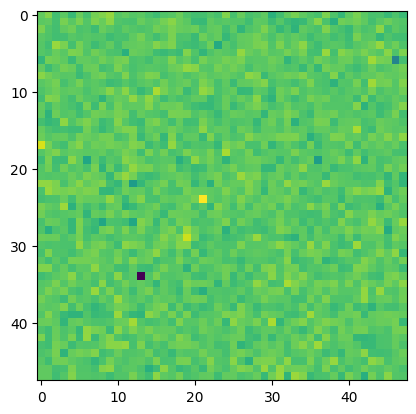

In [16]:
plt.imshow(m[0, -1, :].detach().cpu().numpy().reshape(48,48))

In [17]:
m=cache['blocks.25.hook_mlp_out.hook_sae_acts_post'].detach().cpu().numpy()
# m=cache['blocks.20.attn.hook_z.hook_sae_acts_post']
m.shape

(1, 7, 16384)

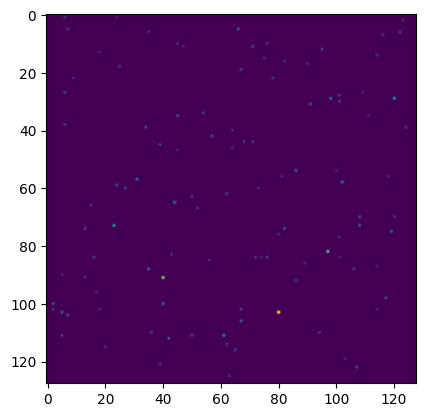

In [18]:
plt.imshow(m[0, -1, :].reshape(128,128))

In [19]:
top_indices = np.argsort(np.abs(m[0,-1]))[-10:][::-1]
m[0,-1][top_indices]

array([49.68829 , 39.851116, 35.822136, 25.93301 , 25.886524, 21.135044,
       17.577877, 17.330416, 16.702261, 16.399277], dtype=float32)

In [20]:
top_indices

array([13264, 11688, 10593,  9367,  3832, 14269,  7526,  7327,  8364,
        3810], dtype=int64)

# Getting features from all layers

(1, 7, 2304)


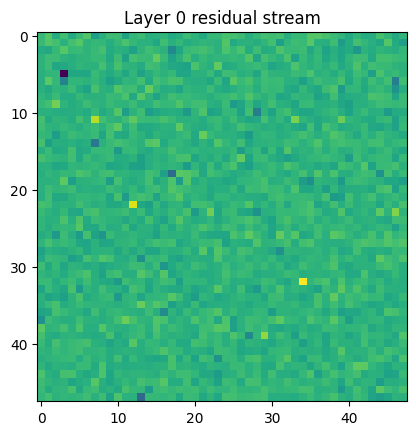

Layer 0 top feature indices: [16248  7697 15083  3851 12681  1024  6214 15188 13552  3088]
(1, 7, 2304)


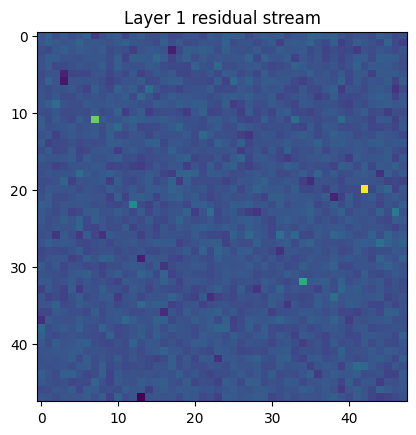

Layer 1 top feature indices: [16282   235  9118  7101   447 11926  7176 12840  7998   451]
(1, 7, 2304)


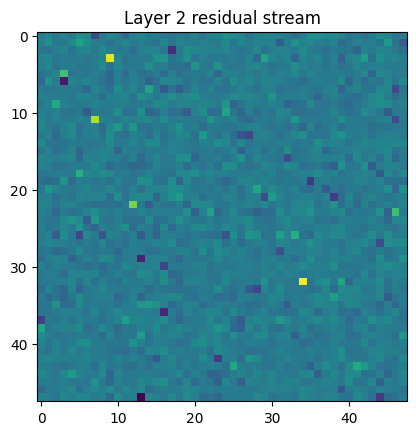

Layer 2 top feature indices: [  191 16370 11249 12695  9765 13891  3310 13276 10246 13506]
(1, 7, 2304)


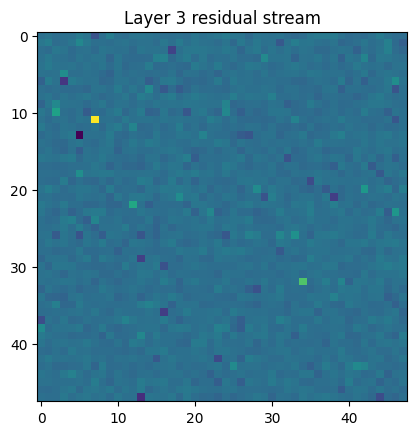

Layer 3 top feature indices: [ 7464  4338   770 14664  4730  5101  6568  4477  4853  7295]
(1, 7, 2304)


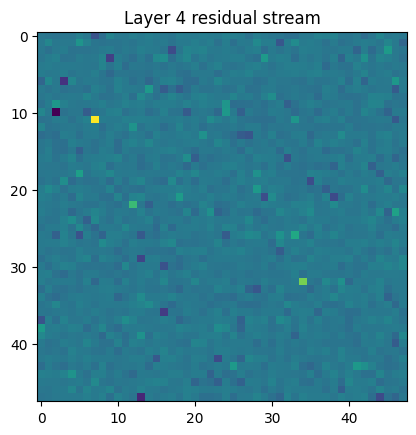

Layer 4 top feature indices: [ 2793 14164 13186  7838  4760  3111  6307  5073  6600 13792]
(1, 7, 2304)


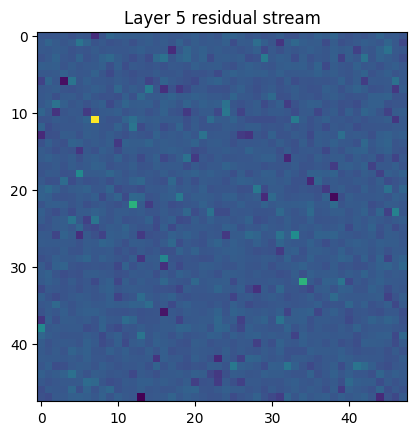

Layer 5 top feature indices: [15592  5830 15439  1268  1383  9115 16017  9237  2932  5781]
(1, 7, 2304)


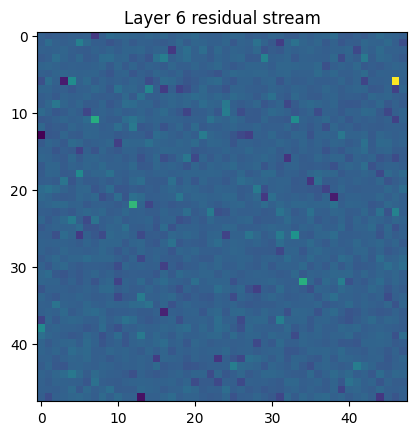

Layer 6 top feature indices: [10878  7589   903  4346 10250 12793  8141 14229 11431 12704]
(1, 7, 2304)


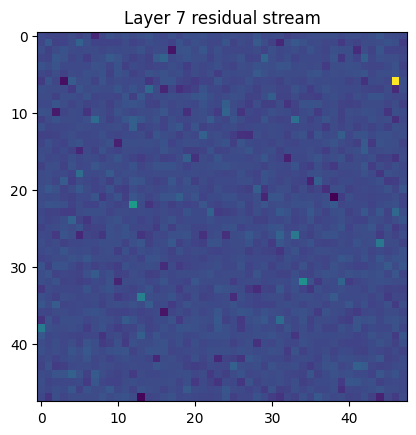

Layer 7 top feature indices: [ 6117  5688 11601 14775 12096  6203 11038  7955  4547   603]
(1, 7, 2304)


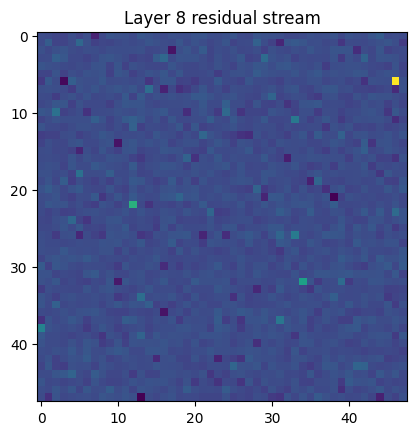

Layer 8 top feature indices: [14760  9158  8978  8331  1096 10938  1631   709  9641  9906]
(1, 7, 2304)


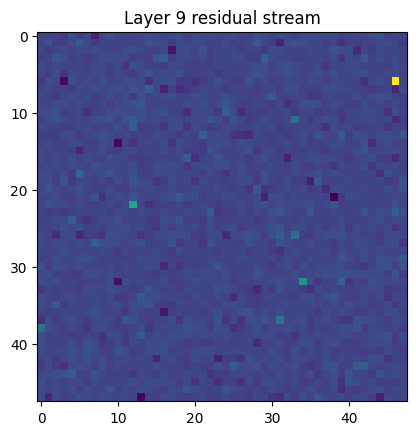

Layer 9 top feature indices: [11525 12242 16248 12405   545   674 10332  9706  8268 11083]
(1, 7, 2304)


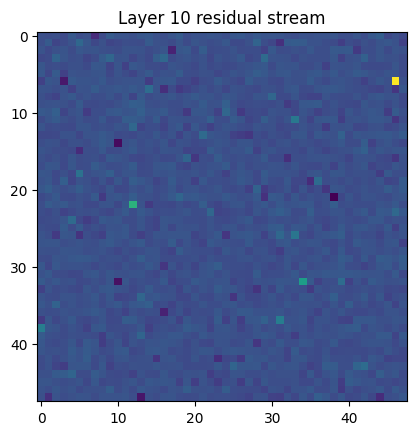

Layer 10 top feature indices: [11314  7495  3721  3704  6881  3876 12978  4422 13237  2440]
(1, 7, 2304)


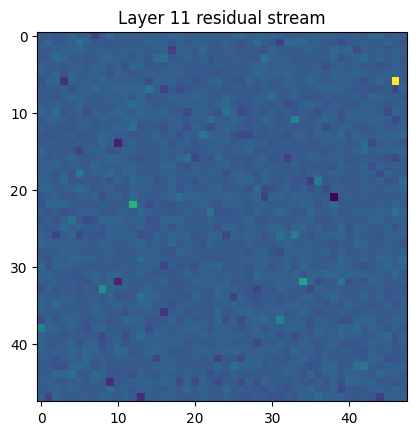

Layer 11 top feature indices: [ 5294  5421  6806  9428 10340  3851  4397 15769  1632 14971]
(1, 7, 2304)


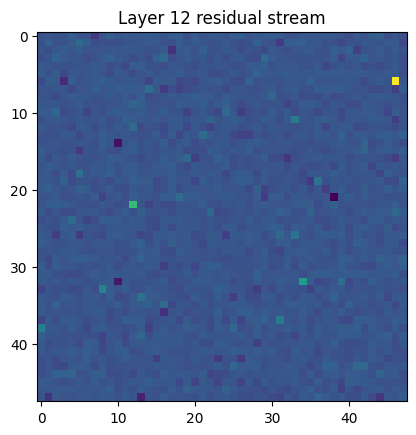

Layer 12 top feature indices: [ 9338  5354   895  1261  5240 11623  8198 12087  5793  8893]
(1, 7, 2304)


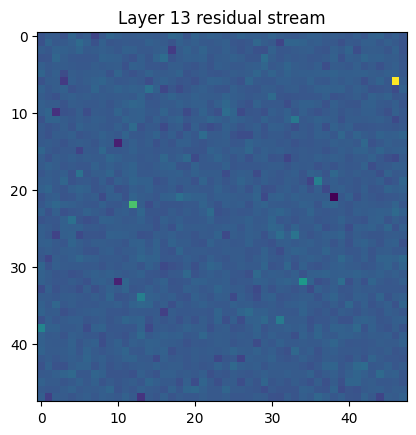

Layer 13 top feature indices: [12072 15672 13617 13429 10462  1107  5773 12560 10826   846]
(1, 7, 2304)


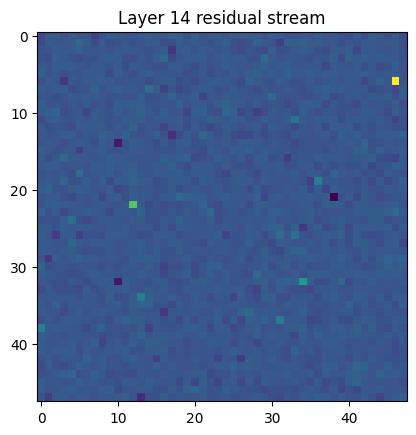

Layer 14 top feature indices: [14250  8506 12828  4988  8361 12935  1878  6266  8681  4015]
(1, 7, 2304)


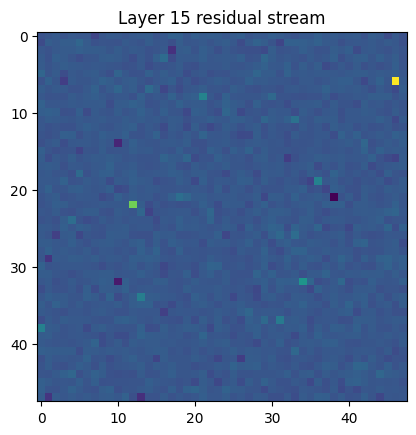

Layer 15 top feature indices: [15052  1220  1790  3812  7097  1373  9804  9463  1686  2383]
(1, 7, 2304)


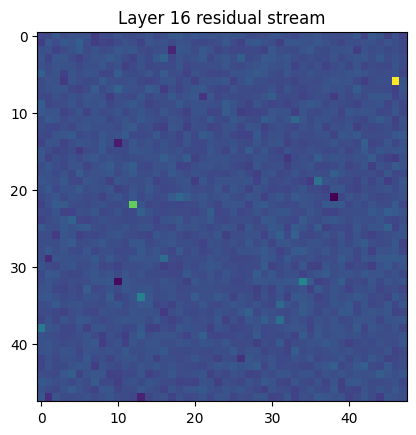

Layer 16 top feature indices: [14896 13749 10571 13211  1314  5867 16186  9218 10241  7761]
(1, 7, 2304)


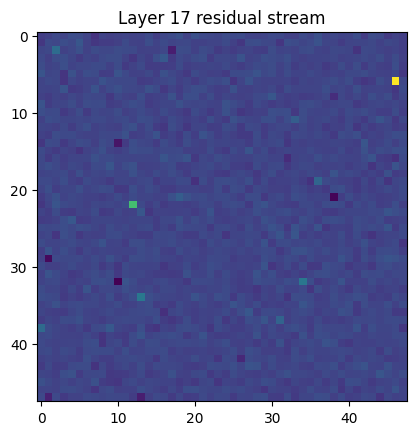

Layer 17 top feature indices: [10089  4957  3659  5845   384 12496 10278 13072 10393   639]
(1, 7, 2304)


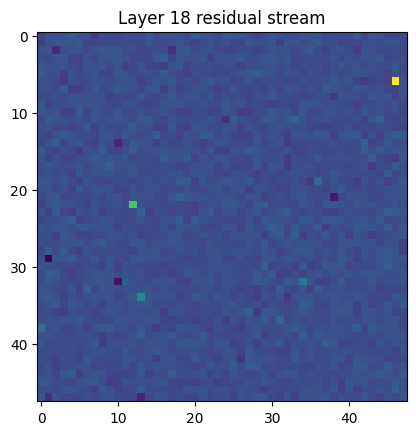

Layer 18 top feature indices: [16336  9756   169  4618 12483 10806  6241 13947   912  9234]
(1, 7, 2304)


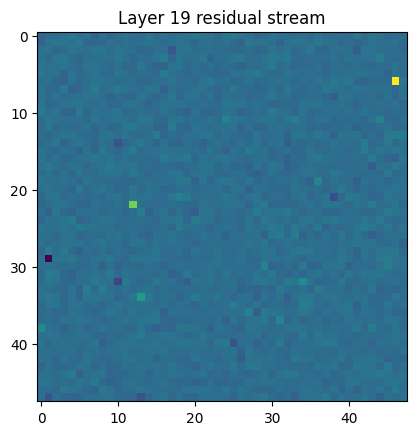

Layer 19 top feature indices: [15523  5830  3299  6769  9504  1070 10474 15253  8787 12947]
(1, 7, 2304)


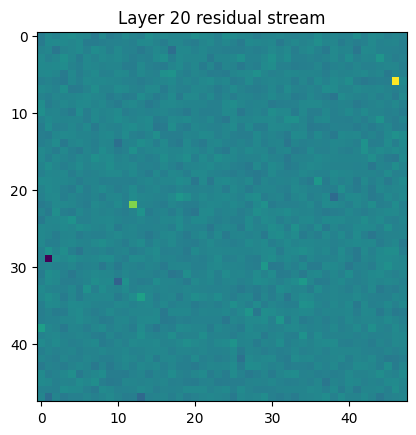

Layer 20 top feature indices: [ 7344  8353 11987  3827  8249 11622 16286 11279 14440 10745]
(1, 7, 2304)


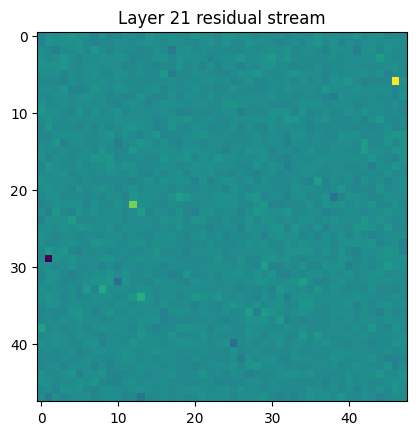

Layer 21 top feature indices: [ 9829  5356  5104 13739 12615 14177 10909 13230 11321  1442]
(1, 7, 2304)


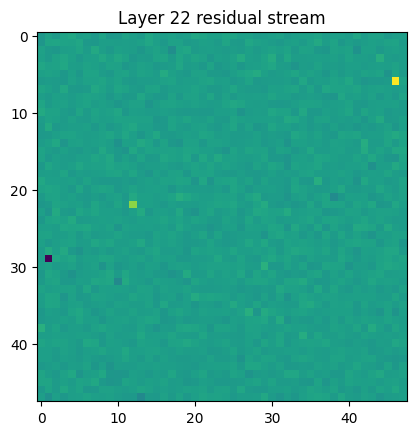

Layer 22 top feature indices: [ 3744  4022 10403   949  6208  9439  2915  3339  3923  2533]
(1, 7, 2304)


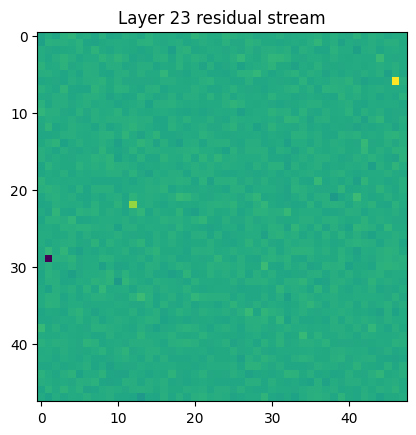

Layer 23 top feature indices: [11253  9992 15178 10184  1320 13242 16190 11401    24   205]
(1, 7, 2304)


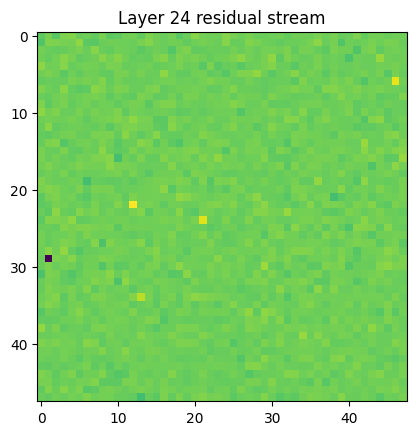

Layer 24 top feature indices: [  282  9329 11721  1040  8185   898  4890  8632 10592  1648]
(1, 7, 2304)


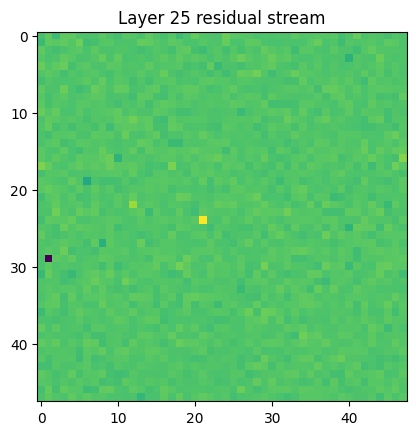

Layer 25 top feature indices: [13264 11688 10593  9367  3832 14269  7526  7327  8364  3810]


In [21]:
features = []
residual_l = []
for i in range(0, 26):
    plt.figure()
    
    m=cache[f'blocks.{str(i)}.hook_mlp_out.hook_sae_acts_post'].detach().cpu().numpy()
    features.append(m)
    # plt.imshow(m[0, -1, :].reshape(128,128))
    # plt.title(f"Layer {str(i)} features")
    # plt.show()
    # plt.close()

    r=cache[f'blocks.{i}.hook_resid_post'].detach().cpu().numpy() # r shape is (1, seq len, 2304)
    print(r.shape)
    residual_l.append(r)
    plt.imshow(r[0, -1, :].reshape(48,48))
    plt.title(f"Layer {str(i)} residual stream")
    plt.show()
    plt.close()
    
    top_indices = np.argsort(np.abs(m[0,-1]))[-10:][::-1]
    print(f"Layer {str(i)} top feature indices: {top_indices}")

# Idea: zero out certain features and see how it affects the downstream features and final output

In [71]:
gemma_2_2b.reset_hooks()
latent_idx=12242        
_steering_hook = partial(
    steering_hook,
    sae=gemma_2_2b_all_sae[9],
    latent_idx=latent_idx,
    steering_coefficient=150,
)

# features_after_steering = []
residual_after_steering = {}

def capture_residual_hook(layer_idx):
    def hook_fn(
        activation: Float[Tensor, "batch pos d_model"],
        hook: HookPoint,
    ) -> None:
        """Capture residual stream for specific layer."""
        residual_after_steering[layer_idx] = activation.clone()
    return hook_fn
# Add hooks to capture residuals
residual_hooks_after_steering = []
for layer in range(26):
    residual_hooks_after_steering.append((f"blocks.{layer}.hook_resid_post", capture_residual_hook(layer)))

# with gemma_2_2b.hooks(fwd_hooks=[("blocks.20.hook_mlp_out", _steering_hook), *residual_hooks_after_steering]):
#     _, cache = gemma_2_2b.run_with_cache_with_saes(
#         prompt,
#         saes=gemma_2_2b_all_sae,
#         stop_at_layer=25+1,
#     )

In [72]:
with gemma_2_2b.hooks(fwd_hooks=[("blocks.9.hook_mlp_out", _steering_hook), *residual_hooks_after_steering]):
    utils.test_prompt(prompt, answer, gemma_2_2b)

Tokenized prompt: ['<bos>', 'The', ' reliability', ' of', ' Wikipedia', ' is', ' very']
Tokenized answer: [' high']


Performance on answer token:
Rank: 3        Logit: 24.42 Prob:  9.57% Token: | high|

Top 0th token. Logit: 24.99 Prob: 16.81% Token: | important|
Top 1th token. Logit: 24.57 Prob: 11.05% Token: | low|
Top 2th token. Logit: 24.44 Prob:  9.72% Token: | different|
Top 3th token. Logit: 24.42 Prob:  9.57% Token: | high|
Top 4th token. Logit: 24.16 Prob:  7.39% Token: | much|
Top 5th token. Logit: 23.86 Prob:  5.43% Token: | good|
Top 6th token. Logit: 23.59 Prob:  4.18% Token: | poor|
Top 7th token. Logit: 23.41 Prob:  3.48% Token: | useful|
Top 8th token. Logit: 23.15 Prob:  2.69% Token: | dependent|
Top 9th token. Logit: 23.12 Prob:  2.61% Token: | often|


Ranks of the answer tokens: [(' high', 3)]

In [73]:
residual_after_steering[16]

tensor([[[-0.5381,  0.5034,  1.4102,  ...,  0.4079,  4.9547,  0.6291],
         [ 0.6182,  3.1822,  1.0272,  ..., -0.4712,  5.8478,  3.5635],
         [-0.2776,  0.2846, -0.2810,  ...,  1.1706, -1.7662,  3.7325],
         ...,
         [-1.8114, -1.4589,  0.1583,  ..., -0.6355,  0.3341,  0.7426],
         [-3.4202, -0.2592,  1.0337,  ..., -0.1354,  0.4305, -1.5799],
         [-2.3805, -4.0026, -0.0211,  ..., -0.8315,  0.0188,  1.0287]]],
       device='cuda:0', grad_fn=<CloneBackward0>)

In [74]:
gemma_2_2b.reset_hooks()
latent_idx=12242        
_no_steering_hook = partial(
    steering_hook,
    sae=gemma_2_2b_all_sae[9],
    latent_idx=latent_idx,
    steering_coefficient=0,
)

residual_no_steering = {}

def capture_residual_hook_no_steering(layer_idx):
    def hook_fn(
        activation: Float[Tensor, "batch pos d_model"],
        hook: HookPoint,
    ) -> None:
        """Capture residual stream for specific layer."""
        residual_no_steering[layer_idx] = activation.clone()
    return hook_fn
# Add hooks to capture residuals
residual_hooks_no_steering = []
for layer in range(26):
    residual_hooks_no_steering.append((f"blocks.{layer}.hook_resid_post", capture_residual_hook_no_steering(layer)))

# with gemma_2_2b.hooks(fwd_hooks=[("blocks.20.hook_mlp_out", _no_steering_hook), *residual_hooks_no_steering]):
#     _, cache = gemma_2_2b.run_with_cache_with_saes(
#         prompt,
#         saes=gemma_2_2b_all_sae,
#         stop_at_layer=25+1,
#     )

In [75]:
with gemma_2_2b.hooks(fwd_hooks=[("blocks.9.hook_mlp_out", _no_steering_hook), *residual_hooks_no_steering]):
    utils.test_prompt(prompt, answer, gemma_2_2b)

Tokenized prompt: ['<bos>', 'The', ' reliability', ' of', ' Wikipedia', ' is', ' very']
Tokenized answer: [' high']


Performance on answer token:
Rank: 2        Logit: 25.30 Prob: 11.16% Token: | high|

Top 0th token. Logit: 25.89 Prob: 20.21% Token: | important|
Top 1th token. Logit: 25.41 Prob: 12.50% Token: | much|
Top 2th token. Logit: 25.30 Prob: 11.16% Token: | high|
Top 3th token. Logit: 25.27 Prob: 10.80% Token: | low|
Top 4th token. Logit: 25.14 Prob:  9.48% Token: | questionable|
Top 5th token. Logit: 24.59 Prob:  5.47% Token: | poor|
Top 6th token. Logit: 24.40 Prob:  4.55% Token: | good|
Top 7th token. Logit: 23.56 Prob:  1.96% Token: | well|
Top 8th token. Logit: 23.51 Prob:  1.87% Token: | controversial|
Top 9th token. Logit: 23.24 Prob:  1.42% Token: | often|


Ranks of the answer tokens: [(' high', 2)]

In [76]:
residual_no_steering[16]

tensor([[[-0.9963,  0.6470,  1.3317,  ..., -0.6683,  1.6761,  0.5975],
         [-0.9524,  3.2407, -0.5520,  ..., -1.1256,  6.2706,  2.7893],
         [ 0.7137, -1.8357,  0.7244,  ...,  4.7155, -3.9135,  1.0815],
         ...,
         [-2.2559, -3.5518,  0.5691,  ...,  5.1351, -1.3412,  3.2482],
         [-5.2524, -4.5067,  1.1553,  ...,  4.4456,  1.8003,  0.2287],
         [ 0.2677, -5.4488, -1.0563,  ...,  2.7684,  4.4951, -1.4495]]],
       device='cuda:0', grad_fn=<CloneBackward0>)

In [79]:
i = 9
residual_after_steering[i] - residual_no_steering[i]

tensor([[[-0.1323, -2.7471,  0.7777,  ...,  0.8063,  4.7191, -0.2478],
         [-0.1323, -2.7471,  0.7777,  ...,  0.8063,  4.7191, -0.2478],
         [-0.1323, -2.7471,  0.7777,  ...,  0.8063,  4.7191, -0.2478],
         ...,
         [-0.1323, -2.7471,  0.7777,  ...,  0.8063,  4.7191, -0.2478],
         [-0.1323, -2.7471,  0.7777,  ...,  0.8063,  4.7191, -0.2478],
         [-0.1323, -2.7471,  0.7777,  ...,  0.8063,  4.7191, -0.2478]]],
       device='cuda:0', grad_fn=<SubBackward0>)